# Analyze the outputs of K-fold cross validation for tuning the beta parameter

First we need to load some basic datasets. We may use them later

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data path: /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/Amundsen-thermal-output-Yang/thermal-training-data/Thwaites-PIG/training/gridded/
Parameter path: /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/data/post-processing-parameters.csv
Output path: /data-archive/ASE-inference/train-validate-test/
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


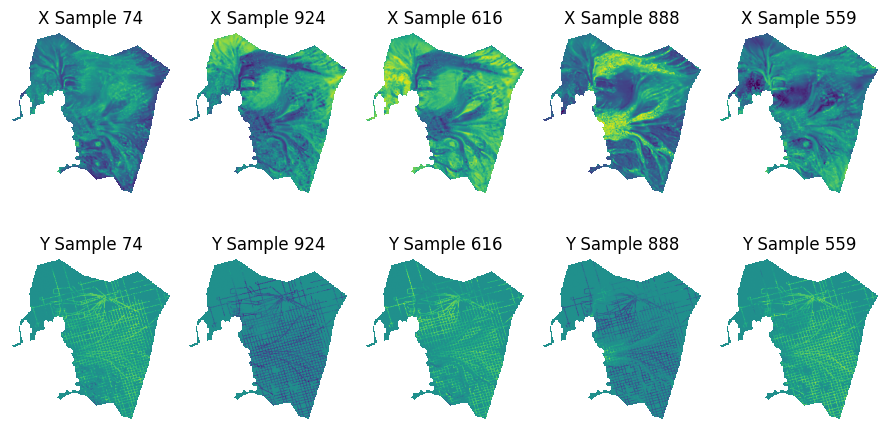

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model
from src.ice import compute_pmp

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
print("Data path:", data_path)
print("Parameter path:", param_path)
print("Output path:", output_path)
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)


# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)

# -----------------------------------------------------------------------------------------------------------------------------
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

# load pmp
md.pmp = pmp

PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (937, 65)
Shape of XY_validation: (0, 65)
Shape of XY_test: (105, 65)
GMM training completed in 1.77 seconds.


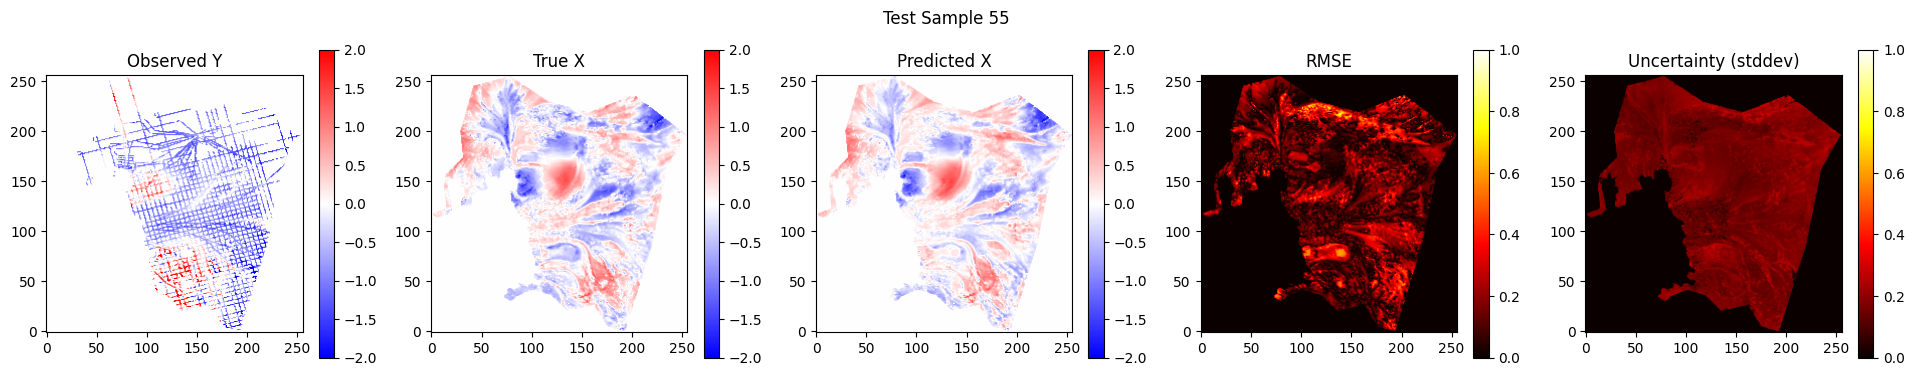

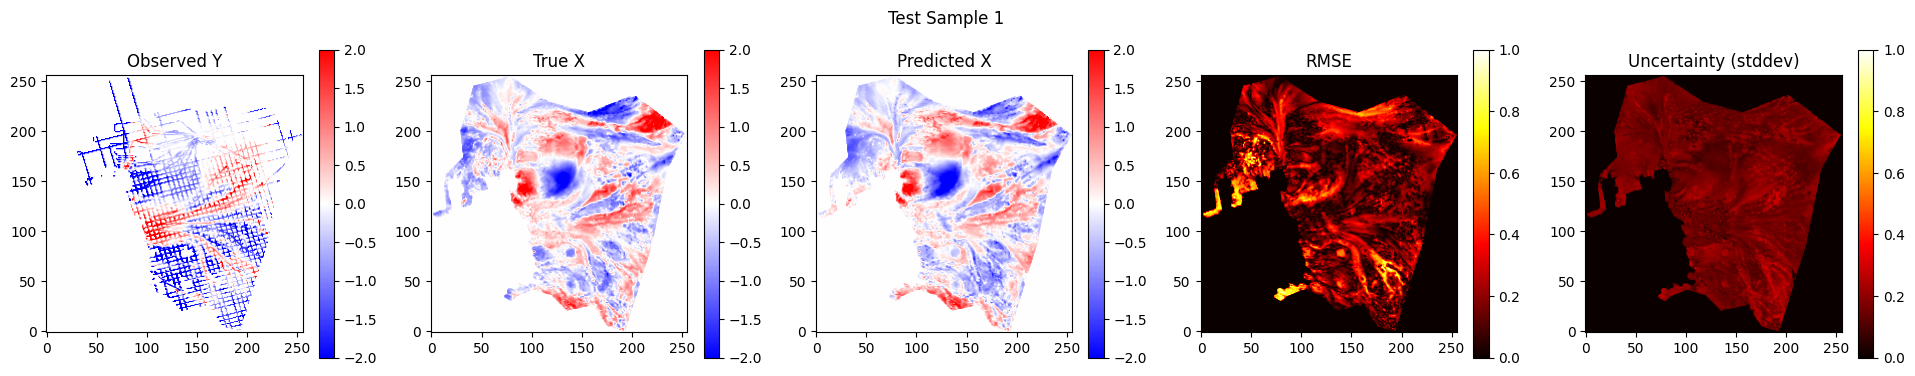

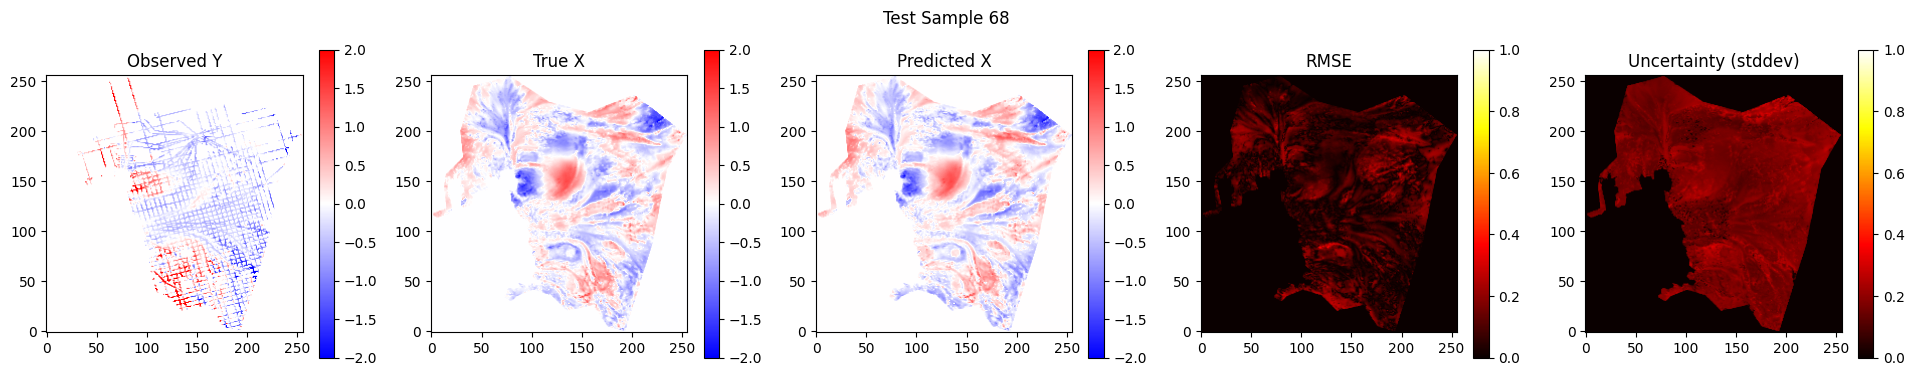

In [2]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=50, n_component_y=15)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)


# based on the BIC sweep plot
n_optimal = 20
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pca(n_samples=3)

shape of Y_obs: (256, 256)


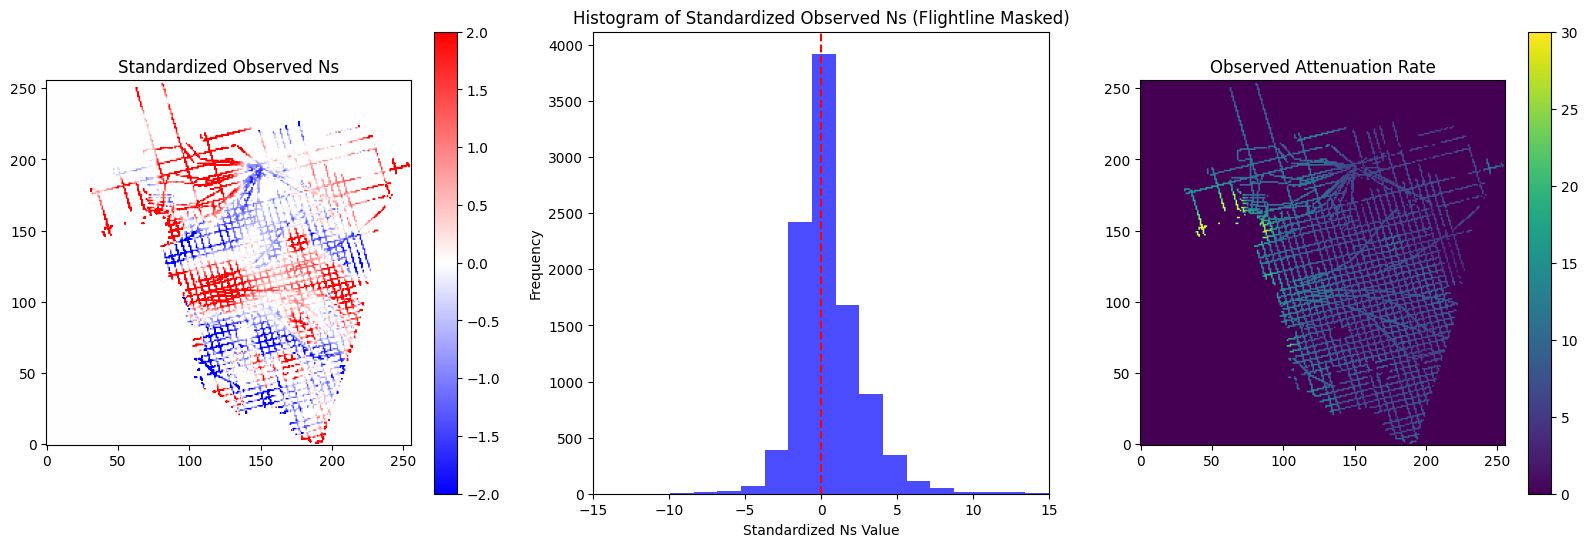

Density at init: [5.57589771e-07]
 Likelihood: 9.688, Prior: 14.400
 Likelihood: 9.728, Prior: 15.544
 Likelihood: 9.357, Prior: 14.495
 Likelihood: 9.327, Prior: 14.500
 Likelihood: 9.316, Prior: 14.494
 Likelihood: 9.295, Prior: 14.504
 Likelihood: 9.286, Prior: 14.510
 Likelihood: 9.276, Prior: 14.518
 Likelihood: 9.275, Prior: 14.519
 Likelihood: 9.275, Prior: 14.519
 Likelihood: 9.275, Prior: 14.519
 Likelihood: 9.275, Prior: 14.519
 Likelihood: 9.275, Prior: 14.519
Optimization success: True
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations: 11
Function evaluations: 13
Final objective: 23.7937
Density at init: [5.57589771e-07]
 Likelihood: 4.497, Prior: 14.400
 Likelihood: 4.313, Prior: 14.646
 Likelihood: 4.378, Prior: 14.444
 Likelihood: 4.360, Prior: 14.455
 Likelihood: 4.361, Prior: 14.445
 Likelihood: 4.357, Prior: 14.446
 Likelihood: 4.354, Prior: 14.449
 Likelihood: 4.352, Prior: 14.450
 Likelihood: 4.350, Prior: 14.452
 Likelihood: 4.350, Prior: 14.451
 Likelihoo

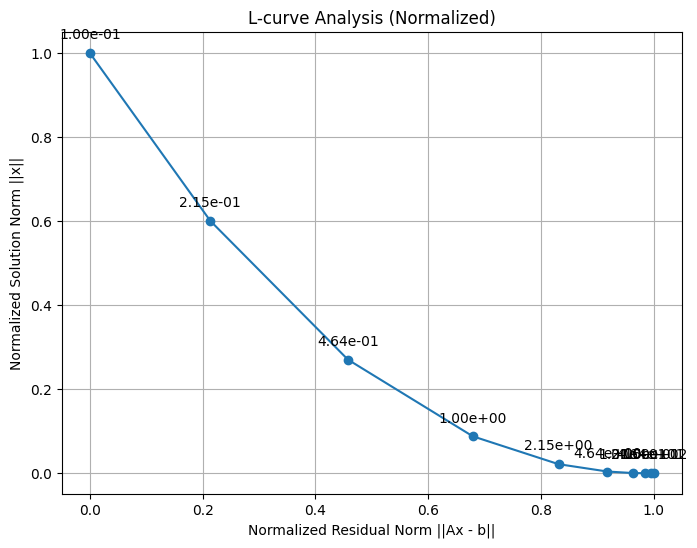

Density at init: [5.57589771e-07]
 Likelihood: 96876.394, Prior: 14.400
 Likelihood: 307831.287, Prior: 158.658
 Likelihood: 89161.580, Prior: 18.003
 Likelihood: 88024.938, Prior: 20.088
 Likelihood: 82893.722, Prior: 57.066
 Likelihood: 80955.695, Prior: 91.315
 Likelihood: 79103.417, Prior: 150.632
 Likelihood: 78142.053, Prior: 143.212
 Likelihood: 77615.954, Prior: 131.637
 Likelihood: 77486.101, Prior: 126.939
 Likelihood: 77265.520, Prior: 121.330
 Likelihood: 77203.527, Prior: 122.461
 Likelihood: 77182.254, Prior: 123.010
 Likelihood: 77172.528, Prior: 124.403
 Likelihood: 77168.298, Prior: 125.264
 Likelihood: 77167.359, Prior: 125.010
 Likelihood: 77166.191, Prior: 124.667
 Likelihood: 77163.845, Prior: 124.070
 Likelihood: 77160.111, Prior: 123.289
 Likelihood: 77157.912, Prior: 122.854
 Likelihood: 77156.371, Prior: 122.971
 Likelihood: 77156.071, Prior: 123.064
 Likelihood: 77156.025, Prior: 123.093
 Likelihood: 77156.026, Prior: 123.092
 Likelihood: 77156.038, Prior: 123

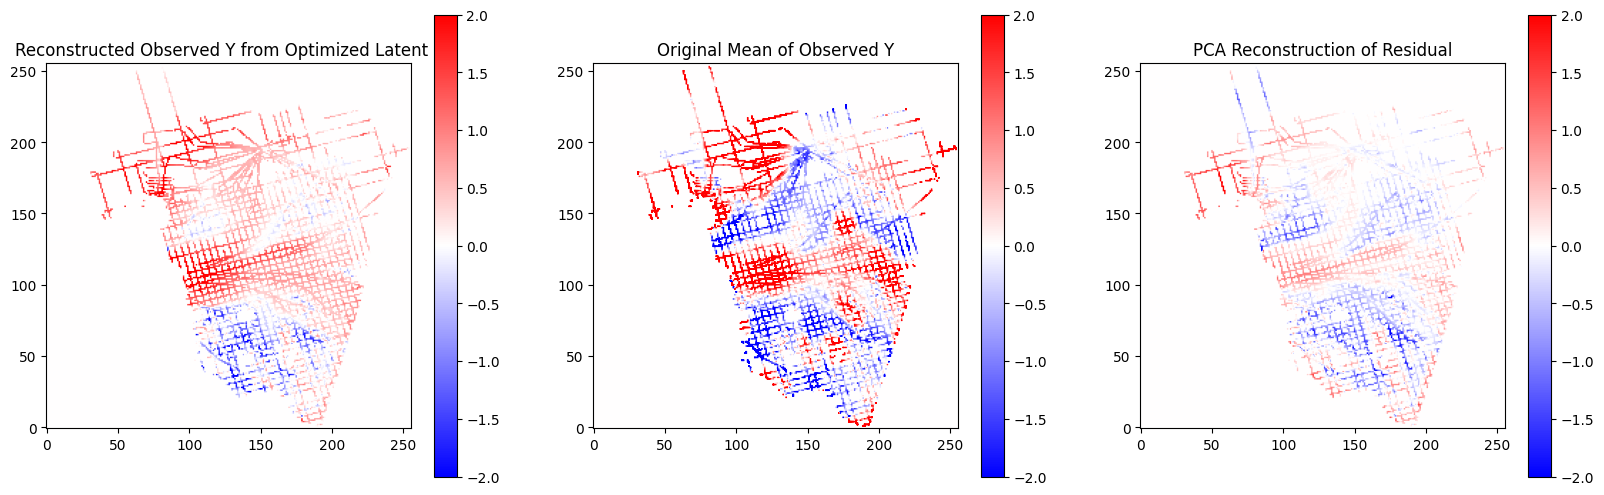

first 5x5 block of cov_obs_latent:
[[ 3.49958769e+04  4.65193135e-04  9.62505064e-05 -7.87696028e-04]
 [ 4.65193135e-04  3.04983835e+03  5.75985036e-03 -4.71375312e-02]
 [ 9.62505064e-05  5.75985036e-03  1.40931144e+03 -9.75296260e-03]
 [-7.87696028e-04 -4.71375312e-02 -9.75296260e-03  4.21227339e+02]]
min eigenvalue: 41.48244400888517
conditioned indices are:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


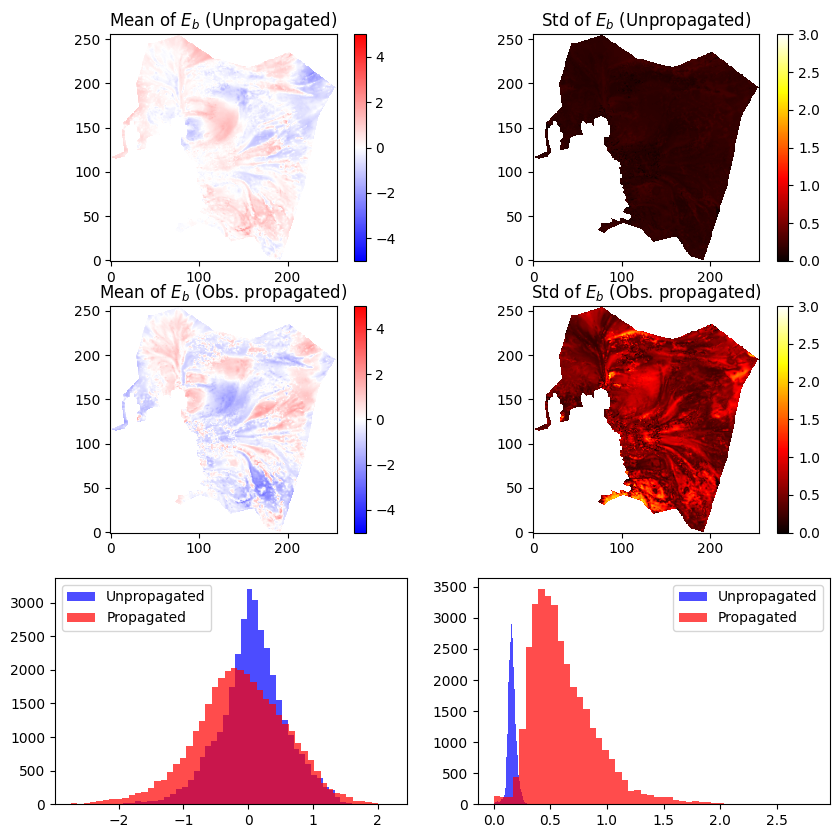

In [22]:
md.load_obs_data(atten_rate_avg)

from src.validation import lcurve_analysis
def opt_func(beta):
    return md.compute_optimal_Y_in_latent(beta=beta, show_plot=False)

beta_prior_list = np.logspace(-1, 2, 10)
lcurve_analysis(opt_func=opt_func, beta_prior_list=beta_prior_list)


# the beta_prior comes from the L-curve plot
beta_prior = 0.00001
lambda1, lambda2 = 1,5
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

# K-Fold Cross Validation with thinning

For each k-fold split data set, we apply varying degrees of thinning (i.e. random subsampling) for the MAP estimation, and for each thinning level we sweep through several choices of beta (the temperature scale factor in the likelihood function). 

In [27]:
from src.validation import split_evidence
from src.optimization import loglikelihoods_sum
import torch
import contextlib
import copy
beta_w = 0.01
beta_posterior_list = [0.5, 1, 2, 3, 4, 5]
thinning_levels = [0.1, 0.2, 0.3] # 10%, 20%, 30% thinning
cv_data_folder = os.getenv('INFERENCE_READY_DATA_PATH')

cv_fold_area_strpattern = "cv_fold_{}_areas.npz"
cv_fold_mask_strpattern = "cv_fold_{}_masks.npz"

# determine the total number of folds by checking the files in the cv_data_folder
cv_fold_area_files = [f for f in os.listdir(cv_data_folder) if f.startswith("cv_fold_") and f.endswith("_areas.npz")]
cv_fold_mask_files = [f for f in os.listdir(cv_data_folder) if f.startswith("cv_fold_") and f.endswith("_masks.npz")]
num_folds = len(cv_fold_area_files)
print("Number of folds detected:", num_folds)

# load one as an xample
data_area_example = np.load(os.path.join(cv_data_folder, cv_fold_area_strpattern.format(0)))
data_mask_example = np.load(os.path.join(cv_data_folder, cv_fold_mask_strpattern.format(0)))
# print the keys of the loaded data
print("Keys in area example:", data_area_example.keys())
print("Keys in mask example:", data_mask_example.keys())

Number of folds detected: 10
Keys in area example: KeysView(NpzFile '/data-archive/ASE-inference/train-validate-test/cv_fold_0_areas.npz' with keys: fold, val_thawed_area, val_frozen_area, train_thawed_area, train_frozen_area)
Keys in mask example: KeysView(NpzFile '/data-archive/ASE-inference/train-validate-test/cv_fold_0_masks.npz' with keys: fold, val_thawed, val_frozen, train_thawed, train_frozen)


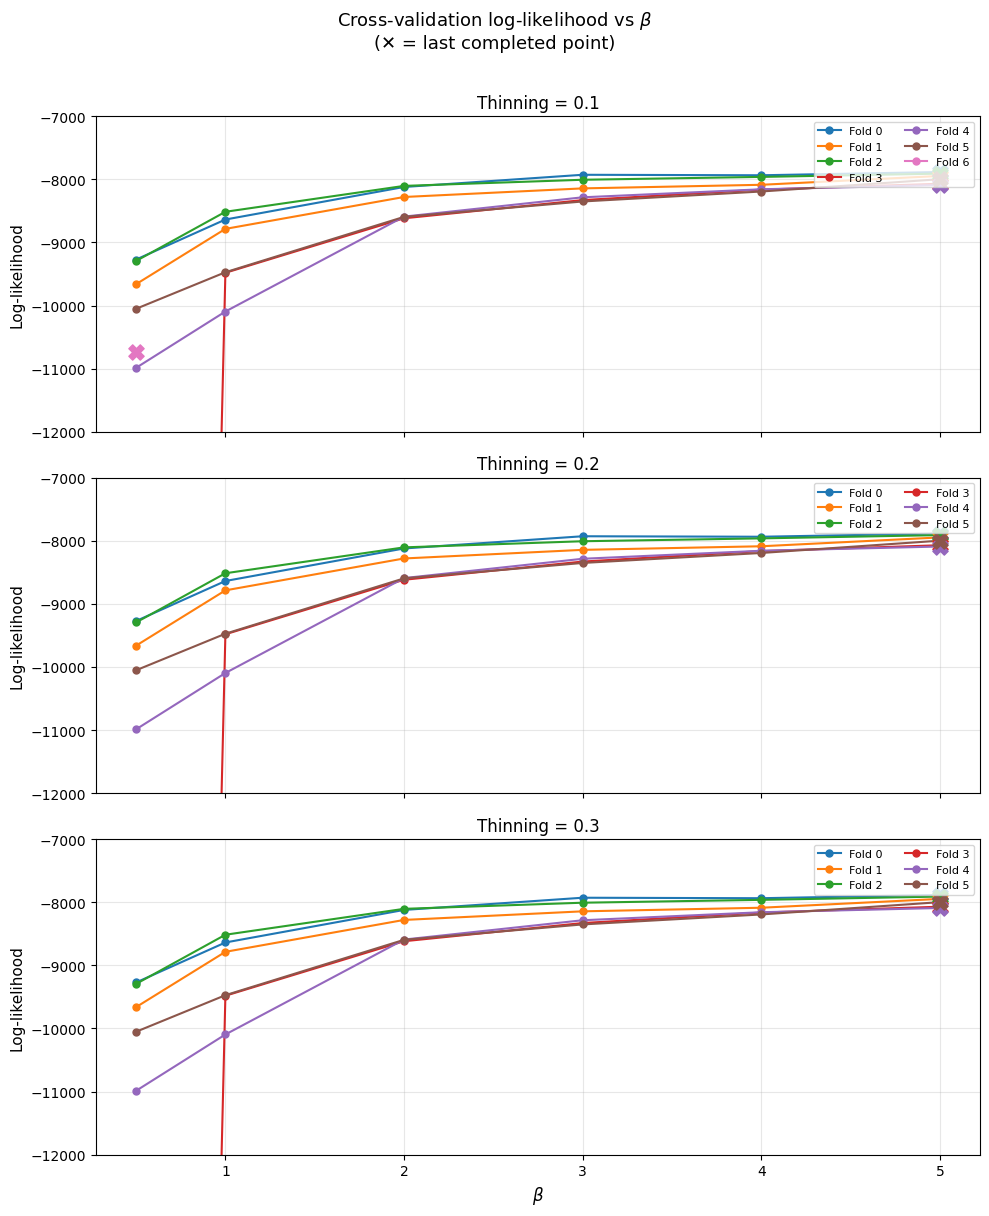

In [38]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(
    len(thinning_levels), 1,
    figsize=(10, 4 * len(thinning_levels)),
    sharex=True
)
if len(thinning_levels) == 1:
    axes = [axes]

colors = cm.tab10(np.linspace(0, 1, num_folds))

for ax, thinning in zip(axes, thinning_levels):
    for fold in range(num_folds):
        # extract the 1D slice for this fold/thinning combo
        ll_slice = ll_betas.sel(fold=fold, thinning=thinning).values  # shape: (n_betas,)

        # find which betas actually have data (not nan)
        valid_mask = ~np.isnan(ll_slice)
        betas_valid = np.array(beta_posterior_list)[valid_mask]
        ll_valid    = ll_slice[valid_mask]

        if len(ll_valid) == 0:
            continue

        ax.plot(betas_valid, ll_valid,
                marker='o', markersize=5,
                color=colors[fold],
                label=f"Fold {fold}")

        # mark the last completed point with an X so you can see where it stopped
        ax.scatter(betas_valid[-1], ll_valid[-1],
                   marker='X', s=120, color=colors[fold], zorder=5)

    ax.set_ylabel("Log-likelihood", fontsize=11)
    ax.set_title(f"Thinning = {thinning}", fontsize=12)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    # ylimit
    ax.set_ylim(-12000, -7000)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')

axes[-1].set_xlabel(r"$\beta$", fontsize=12)
fig.suptitle("Cross-validation log-likelihood vs $\\beta$\n(✕ = last completed point)", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Fold 0, Thinning 0.1:
  Original thawed mask: 2344 true, Original frozen mask: 885 true
  Thinned thawed mask: 2110 true, Thinned frozen mask: 797 true
  Original thawed area: 2344.0000, Original frozen area: 885.0000
  Thinned thawed area: 2110.0000, Thinned frozen area: 797.0000
...processing beta_posterior: 0.5, fold number 0, thinning level 0.1


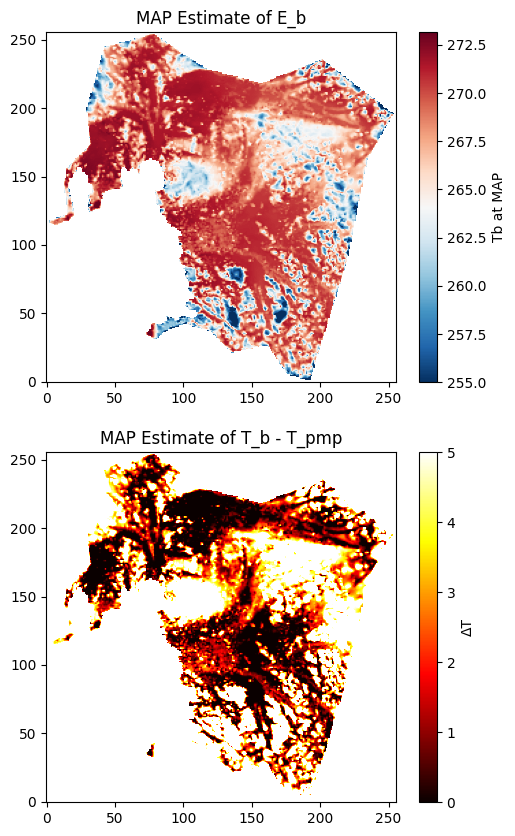

---------> Completed beta_posterior = 0.5
---------> The log-likelihoods for the subsets are: -10166.542993708197
...processing beta_posterior: 1, fold number 0, thinning level 0.1


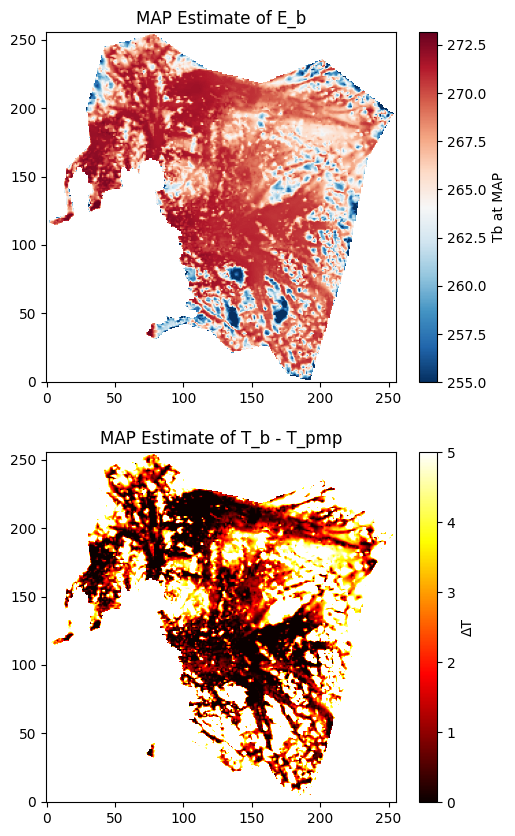

---------> Completed beta_posterior = 1
---------> The log-likelihoods for the subsets are: -8523.7673118531
...processing beta_posterior: 2, fold number 0, thinning level 0.1


KeyboardInterrupt: 

In [ ]:
# create xarray data frame to record ll with fold number, thinning level, and beta_posterior as coordinates
Tb_MAP_betas = xr.DataArray(
    data=np.nan,
    dims=["fold", "thinning", "beta_posterior", "grid_points"],
    coords={
        "fold": np.arange(num_folds),
        "thinning": thinning_levels,
        "beta_posterior": beta_posterior_list,
        "grid_points": np.arange(md.nx * md.ny)
    }
)
ll_betas = xr.DataArray(
    data=np.nan,
    dims=["fold", "thinning", "beta_posterior"],
    coords={
        "fold": np.arange(num_folds),
        "thinning": thinning_levels,
        "beta_posterior": beta_posterior_list
    }
)

error_collect = []

# suppress output 
np.random.seed(42)  # for reproducibility
# for fold in range(num_folds):
for fold in range(2):
    # load the areas and masks for this fold
    data_area = np.load(os.path.join(cv_data_folder, cv_fold_area_strpattern.format(fold)))
    data_mask = np.load(os.path.join(cv_data_folder, cv_fold_mask_strpattern.format(fold)))

    # extract the training and test areas and masks
    fold_num = data_mask['fold']
    train_thawed_mask = data_mask['train_thawed'].ravel()
    train_frozen_mask = data_mask['train_frozen'].ravel()
    val_thawed_mask   = data_mask['val_thawed'].ravel()
    val_frozen_mask   = data_mask['val_frozen'].ravel()

    train_thawed_frac = data_area['train_thawed_area'].ravel()  
    train_frozen_frac = data_area['train_frozen_area'].ravel()
    val_thawed_frac   = data_area['val_thawed_area'].ravel()
    val_frozen_frac   = data_area['val_frozen_area'].ravel()

    for thinning in thinning_levels:
        # randomly thin the training data based on the thinning level
        train_thawed_mask_thinned = train_thawed_mask.copy()
        train_frozen_mask_thinned = train_frozen_mask.copy()
        train_thawed_frac_thinned = train_thawed_frac.copy()
        train_frozen_frac_thinned = train_frozen_frac.copy()

        # randomly set a fraction of the training masks to False based on the thinning level
        train_thawed_indices = np.where(train_thawed_mask)[0]
        train_frozen_indices = np.where(train_frozen_mask)[0]
        num_thawed_to_remove = int(thinning * len(train_thawed_indices))
        num_frozen_to_remove = int(thinning * len(train_frozen_indices))
        thinned_thawed_indices = np.random.choice(train_thawed_indices, size=num_thawed_to_remove, replace=False)
        thinned_frozen_indices = np.random.choice(train_frozen_indices, size=num_frozen_to_remove, replace=False)
        train_thawed_mask_thinned[thinned_thawed_indices] = False
        train_frozen_mask_thinned[thinned_frozen_indices] = False
        train_thawed_frac_thinned[thinned_thawed_indices] = 0.0
        train_frozen_frac_thinned[thinned_frozen_indices] = 0.0
        # consistency check: report total number of true in both masks, and total area in both fractions
        print(f"Fold {fold}, Thinning {thinning}:")
        print(f"  Original thawed mask: {np.sum(train_thawed_mask)} true, Original frozen mask: {np.sum(train_frozen_mask)} true")
        print(f"  Thinned thawed mask: {np.sum(train_thawed_mask_thinned)} true, Thinned frozen mask: {np.sum(train_frozen_mask_thinned)} true")
        print(f"  Original thawed area: {np.sum(train_thawed_frac):.4f}, Original frozen area: {np.sum(train_frozen_frac):.4f}")
        print(f"  Thinned thawed area: {np.sum(train_thawed_frac_thinned):.4f}, Thinned frozen area: {np.sum(train_frozen_frac_thinned):.4f}")

        for beta_posterior in beta_posterior_list:
            md_copy = copy.deepcopy(md)  # deepcopy, not copy.copy
            print(f"...processing beta_posterior: {beta_posterior}, fold number {fold}, thinning level {thinning}")
            Tb_MAP_subsets = []
            ll_subsets = []

            # ── Fit on training set ───────────────────────────────────────
            try:
                with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
                    md_copy.load_evidence(train_thawed_mask_thinned, train_thawed_frac_thinned,
                                            train_frozen_mask_thinned, train_frozen_frac_thinned,
                                            pmp, show_plot=False)
                    md_copy.compute_MAP(beta=beta_posterior, beta_w = beta_w, n_iter=20, lr=0.5, show_plot=False)

                # ── Evaluate on held-out test fold ────────────────────────────
                Tb_MAP_subsets.append(md_copy.Tb_MAP.copy())
                Tb_flat = md_copy.Tb_MAP.copy().flatten()
                Eb_flat = md_copy.Eb_MAP.copy().flatten()
                Tb_flat[np.isnan(Tb_flat)] = 0.0
                Eb_flat[np.isnan(Eb_flat)] = 0.0

                with torch.no_grad():
                    ll = loglikelihoods_sum(beta_posterior,
                                            beta_w,
                                            torch.from_numpy(Tb_flat),
                                            torch.from_numpy(Eb_flat),
                                            torch.from_numpy(pmp),
                                            torch.from_numpy(val_thawed_frac), 
                                            torch.from_numpy(val_frozen_frac)) 
                ll_subsets.append(ll)

                # save results to xarray
                Tb_MAP_betas.loc[fold, thinning, beta_posterior, :] = Tb_MAP_subsets[0].ravel()
                ll_betas.loc[fold, thinning, beta_posterior]        = ll_subsets[0]

            # catch the error and just keep it as nan
            except Exception as e:
                print(f"Error occurred for beta_posterior {beta_posterior}, fold {fold}, thinning {thinning}: {e}")
                Tb_MAP_betas.loc[fold, thinning, beta_posterior, :] = np.nan
                ll_betas.loc[fold, thinning, beta_posterior]        = np.nan
                # save the error 
                error_collect.append({
                    "fold": fold,
                    "thinning": thinning,
                    "beta_posterior": beta_posterior,
                    "error_message": str(e)
                })

            print(f"---------> Completed beta_posterior = {beta_posterior}")
            print(f"---------> The log-likelihoods for the subsets are: {ll_subsets[0]}")


# Load the HMC posterior models

Loaded samples from /data-archive/ASE-inference/posteriors/models/mcmc_run_beta_1.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_1.0_kfold_0_ori.npy and /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_1.0_kfold_0_norm.npy
Finished analyzing posterior samples for beta = 1.0 kfold = 0
--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 1601.73
Minimum ESS (Worst mixing dimension): 922.28
Maximum ESS (Best mixing dimension): 2404.11
Post-Burn-in Mean ESS: 997.91
Post-Burn-in Min ESS: 561.33


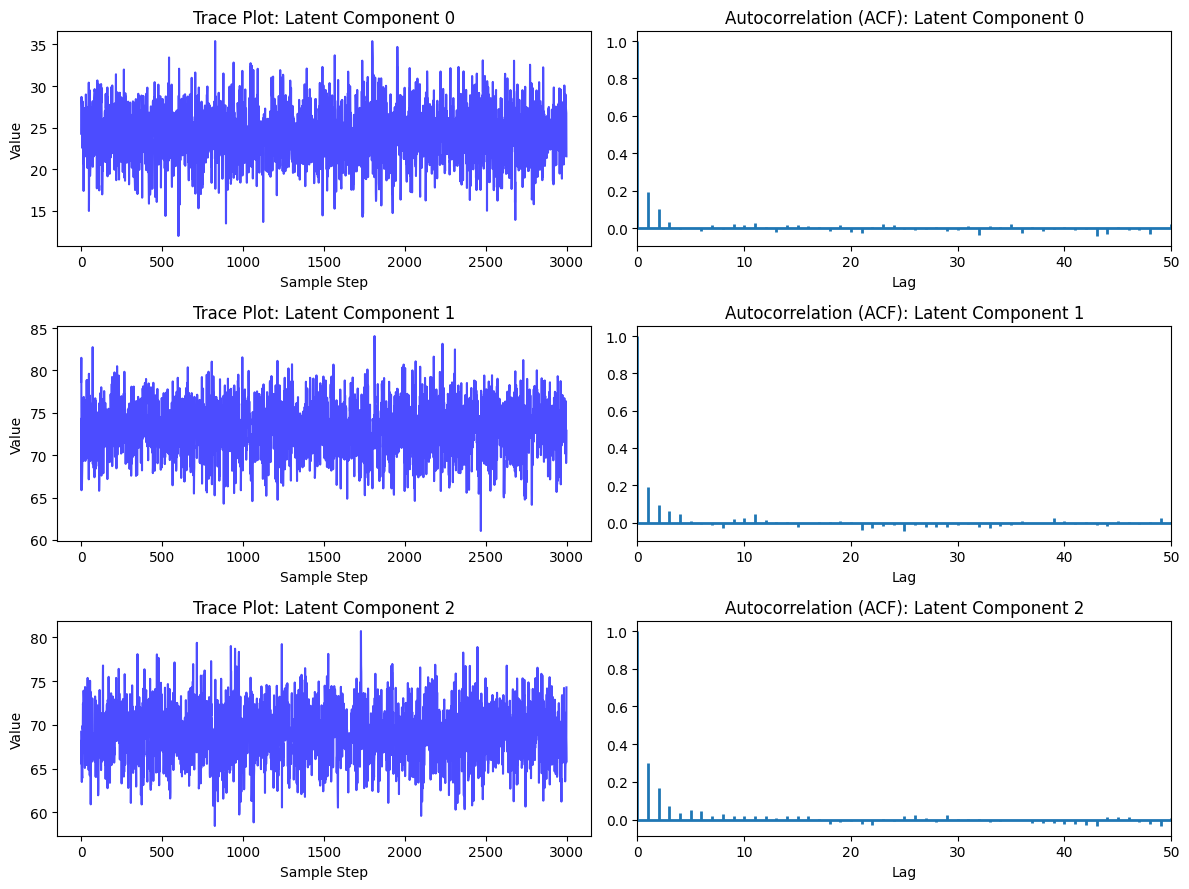

Loaded samples from /data-archive/ASE-inference/posteriors/models/mcmc_run_beta_2.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_2.0_kfold_0_ori.npy and /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_2.0_kfold_0_norm.npy
Finished analyzing posterior samples for beta = 2.0 kfold = 0
--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 2297.65
Minimum ESS (Worst mixing dimension): 1303.01
Maximum ESS (Best mixing dimension): 3152.43
Post-Burn-in Mean ESS: 1532.58
Post-Burn-in Min ESS: 942.77


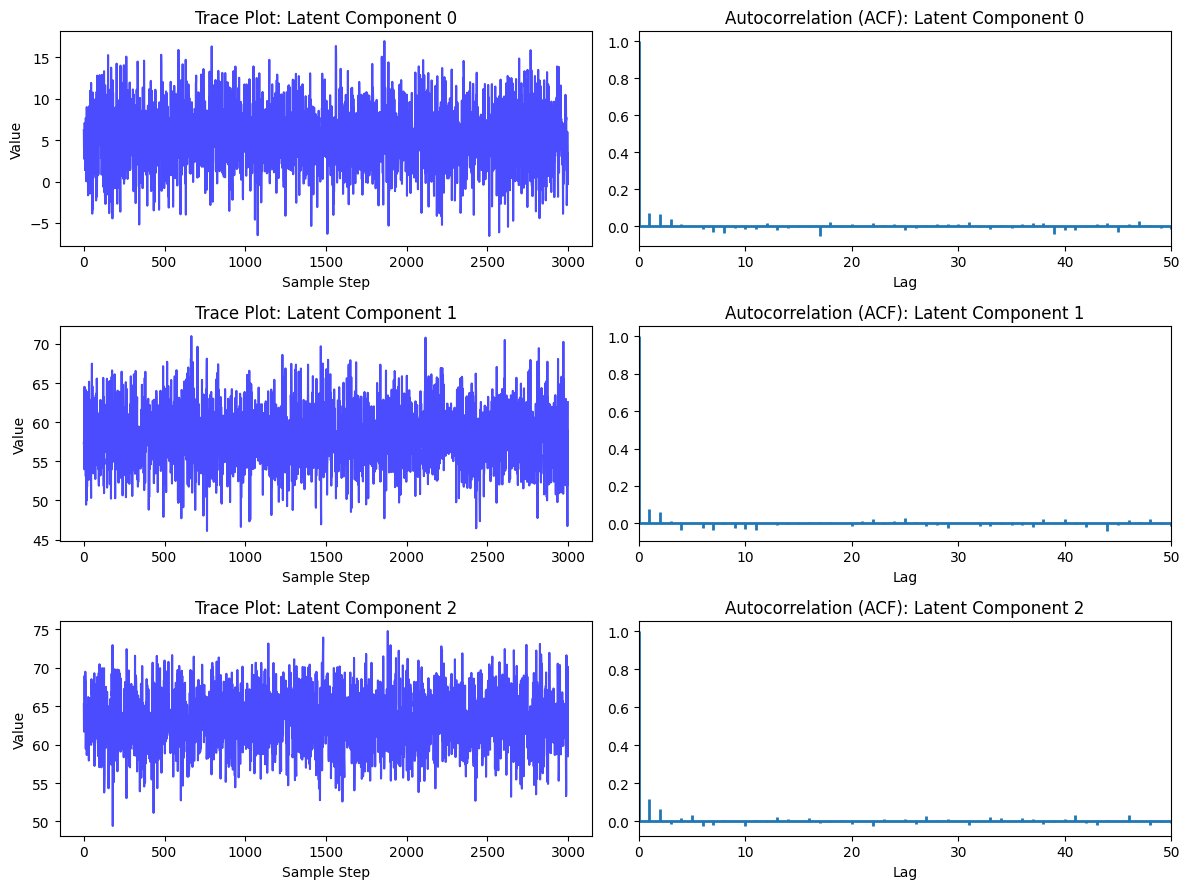

Loaded samples from /data-archive/ASE-inference/posteriors/models/mcmc_run_beta_3.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_3.0_kfold_0_ori.npy and /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_3.0_kfold_0_norm.npy
Finished analyzing posterior samples for beta = 3.0 kfold = 0
--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 2832.22
Minimum ESS (Worst mixing dimension): 2080.56
Maximum ESS (Best mixing dimension): 3778.18
Post-Burn-in Mean ESS: 1811.65
Post-Burn-in Min ESS: 1353.70


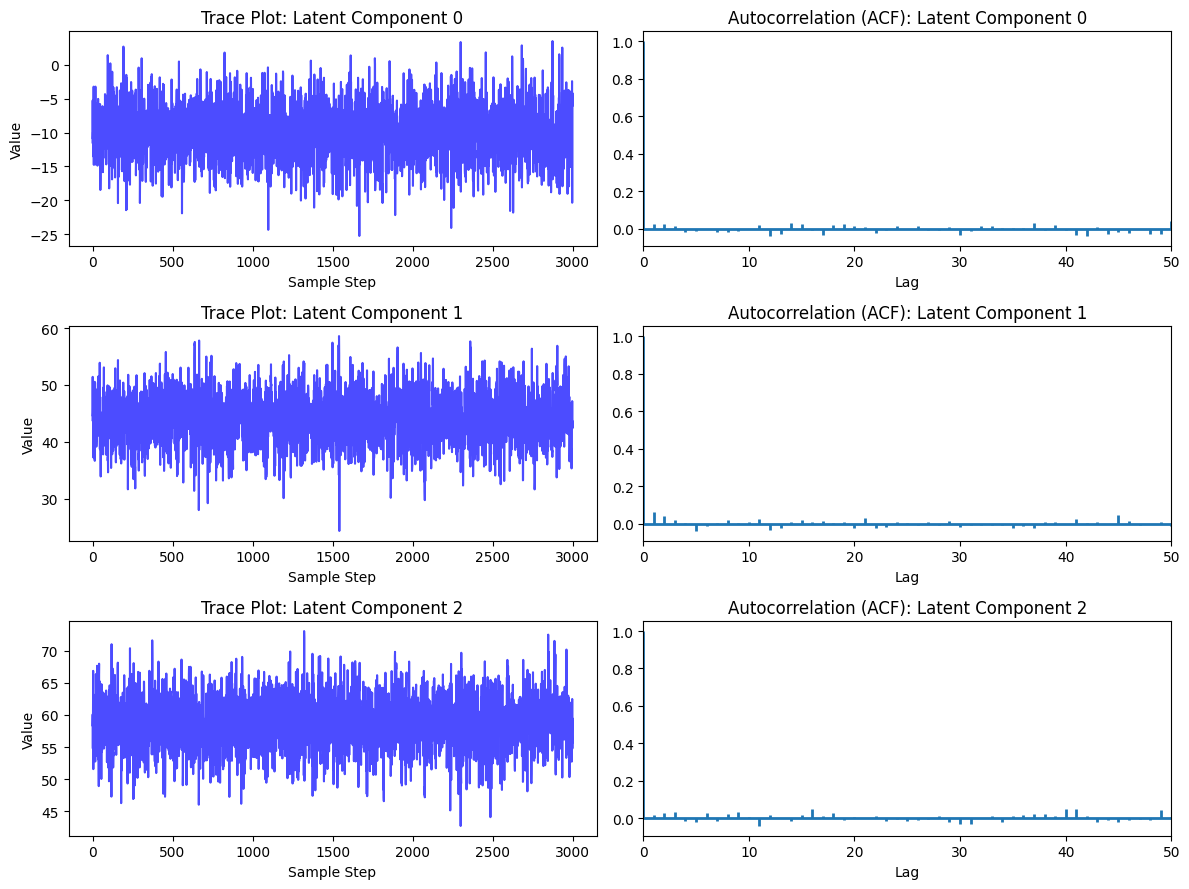

In [ ]:
import copy

posterior_md_path = "/data-archive/ASE-inference/posteriors/models/"
posterior_samples_path = "/data-archive/ASE-inference/posteriors/samples/"
md_name_pattern = "mcmc_run_beta_{}_kfold_{}.pt"

# load all the posterior models for different beta and kfold
beta_list = [1.0, 2.0, 3.0]
kfold_list = [0]

# md_pristine = copy.deepcopy(md) 

import numpy.dtypes
import torch.serialization

torch.serialization.add_safe_globals([
    np._core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
    np.dtypes.Float64DType,      
    np._core.multiarray.scalar,
])

for beta in beta_list:
    for kfold in kfold_list:
        md_name = md_name_pattern.format(beta, kfold)
        md_path = posterior_md_path + md_name
        samples_path = posterior_samples_path + f"Eb_samples_beta_{beta}_kfold_{kfold}.npy"

        md_copy = copy.deepcopy(md)
        md_copy.analyze_posterior_samples(beta=beta, 
                                          beta_w=0.01, 
                                          loading=True,
                                          loadname=md_path,
                                          savename=samples_path)
        print("Finished analyzing posterior samples for beta =", beta, "kfold =", kfold)

        md_copy.posterior_quality_check()


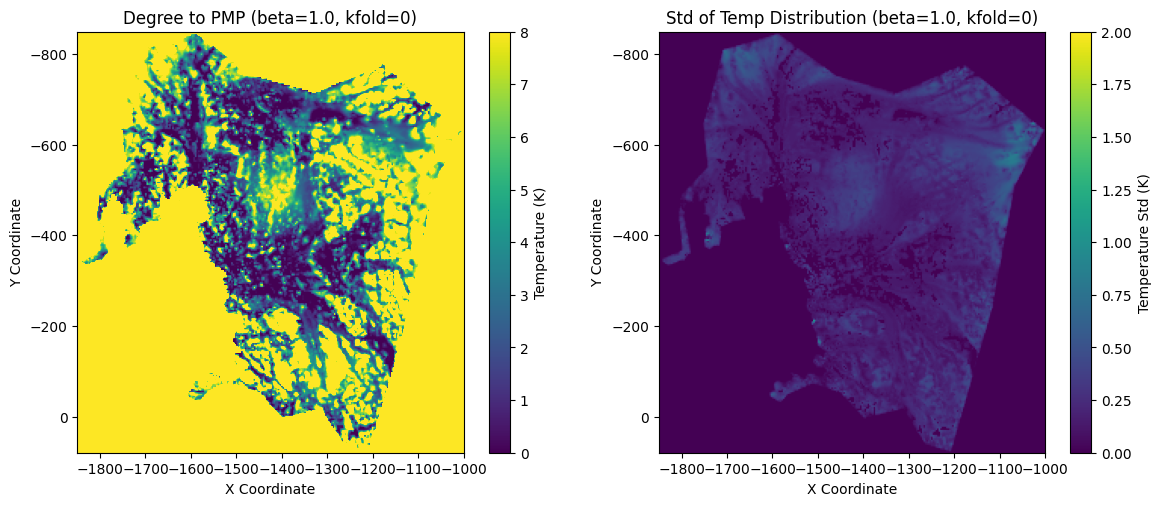

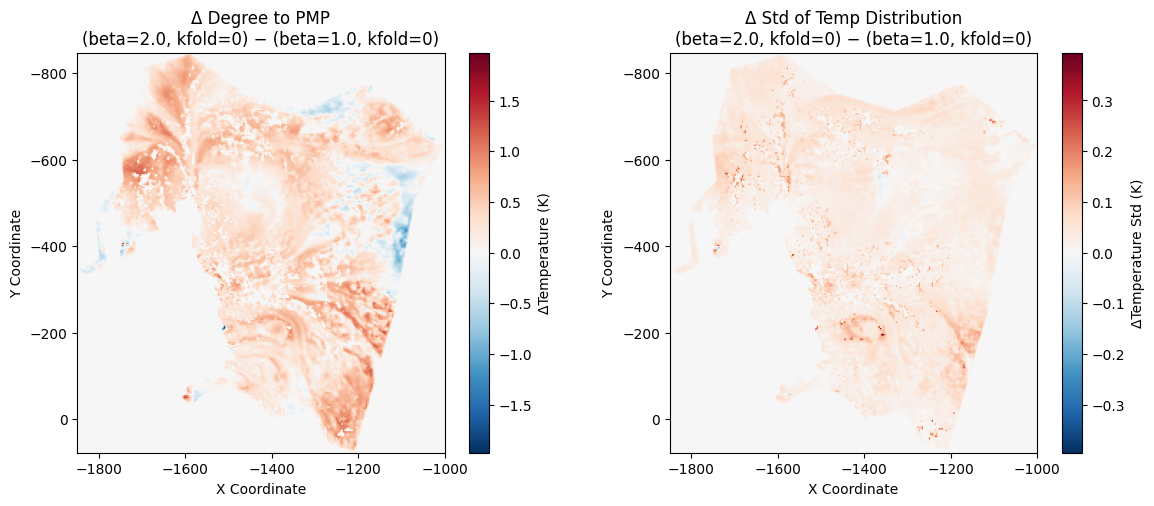

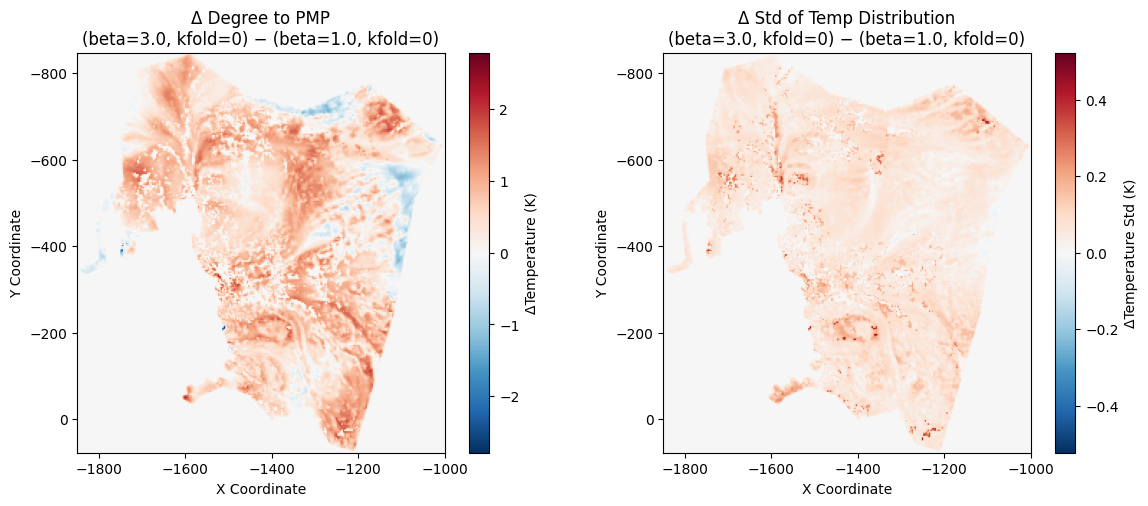

In [60]:
from src.ice import enthalpy_to_temperature

# Storage for reference (first iteration)
ref_Tb_mean = None
ref_Tb_std  = None
ref_beta    = None
ref_kfold   = None

for beta in beta_list:
    for kfold in kfold_list:
        samples_path = posterior_samples_path + f"Eb_samples_beta_{beta}_kfold_{kfold}_ori.npy"
        Eb_samples  = np.load(samples_path)

        # ── Convert to temperature ─────────────────────────────────────────
        Tb_samples  = np.zeros_like(Eb_samples)
        Tpmp_flat   = md.pmp.flatten()
        num_samples = Eb_samples.shape[0]

        for i in range(num_samples):
            Eb_i   = torch.from_numpy(Eb_samples[i])
            Tpmp_i = torch.from_numpy(Tpmp_flat) if isinstance(Tpmp_flat, np.ndarray) else Tpmp_flat
            Tb_samples[i] = enthalpy_to_temperature(Eb_i, Tpmp_i).numpy()

        Tb_std  = np.std(Tb_samples,  axis=0).reshape(md.nx, md.ny)
        Tb_mean = np.mean(Tb_samples, axis=0).reshape(md.nx, md.ny)
        deg_to_pmp = md.pmp.reshape(md.nx, md.ny) - Tb_mean

        # ── First iteration: store as reference ───────────────────────────
        is_first = (ref_Tb_mean is None)
        if is_first:
            ref_Tb_mean = Tb_mean.copy()
            ref_Tb_std  = Tb_std.copy()
            ref_beta    = beta
            ref_kfold   = kfold

        # ── Plot ──────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        if is_first:
            # Absolute maps for the reference run
            im0 = axes[0].imshow(deg_to_pmp, extent=extent, origin='lower', vmin=0, vmax=8)
            axes[0].set_title(f"Degree to PMP (beta={beta}, kfold={kfold})")
            fig.colorbar(im0, ax=axes[0], label='Temperature (K)')

            im1 = axes[1].imshow(Tb_std, extent=extent, origin='lower', vmin=0, vmax=2)
            axes[1].set_title(f"Std of Temp Distribution (beta={beta}, kfold={kfold})")
            fig.colorbar(im1, ax=axes[1], label='Temperature Std (K)')

        else:
            # Difference maps relative to the first run
            diff_mean = deg_to_pmp - (md.pmp.reshape(md.nx, md.ny) - ref_Tb_mean)
            diff_std  = Tb_std - ref_Tb_std

            # Symmetric colormap centered at zero
            abs_max_mean = np.nanmax(np.abs(diff_mean))
            abs_max_std  = np.nanmax(np.abs(diff_std))

            im0 = axes[0].imshow(diff_mean, extent=extent, origin='lower',
                                 cmap='RdBu_r', vmin=-abs_max_mean, vmax=abs_max_mean)
            axes[0].set_title(
                f"Δ Degree to PMP\n(beta={beta}, kfold={kfold}) − (beta={ref_beta}, kfold={ref_kfold})"
            )
            fig.colorbar(im0, ax=axes[0], label='ΔTemperature (K)')

            im1 = axes[1].imshow(diff_std, extent=extent, origin='lower',
                                 cmap='RdBu_r', vmin=-abs_max_std, vmax=abs_max_std)
            axes[1].set_title(
                f"Δ Std of Temp Distribution\n(beta={beta}, kfold={kfold}) − (beta={ref_beta}, kfold={ref_kfold})"
            )
            fig.colorbar(im1, ax=axes[1], label='ΔTemperature Std (K)')

        for ax in axes:
            ax.set_xlabel("X Coordinate")
            ax.set_ylabel("Y Coordinate")

        plt.tight_layout()
        plt.show()
